In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [14]:
DATA_DIR = '/kaggle/input/datasets/vivdychenkomaksym/lab-6-data/lab-6 data/logos3/data'

img_size = (150, 150)
batch_size = 32

datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

datagen_test = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("Завантаження тренувального набору:")
train_generator = datagen_train.flow_from_directory(
    directory=DATA_DIR,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

print("\nЗавантаження валідаційного/тестового набору:")
val_generator = datagen_test.flow_from_directory(
    directory=DATA_DIR,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print(f"\nКласи знайдено: {class_names}")

Завантаження тренувального набору:
Found 847 images belonging to 2 classes.

Завантаження валідаційного/тестового набору:
Found 211 images belonging to 2 classes.

Класи знайдено: ['Other', 'Starbucks']


In [15]:
def build_xception(input_shape=(150, 150, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(16, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    skip = layers.Conv2D(32, (1, 1), strides=(2, 2), padding='same')(x)
    skip = layers.BatchNormalization()(skip)
    
    x = layers.SeparableConv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)
    x = layers.add([x, skip])
    
    skip = layers.Conv2D(64, (1, 1), strides=(2, 2), padding='same')(x)
    skip = layers.BatchNormalization()(skip)
    
    x = layers.SeparableConv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)
    x = layers.add([x, skip])
    
    x = layers.SeparableConv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(num_classes)(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

model = build_xception()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 150, 150,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │         64 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 150, 150,  │        688 │ activation_8[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 75, 75,    │        544 │ activation_8[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 75, 75,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 75, 75,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 75, 75,    │      2,400 │ add_4[0][0]       │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 38, 38,    │      2,112 │ add_4[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 38, 38,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 38,    │        256 │ conv2d_8[0][0]  

 Total params: 20,593 (80.44 KB)

 Trainable params: 19,921 (77.82 KB)

 Non-trainable params: 672 (2.62 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 551ms/step - accuracy: 0.7730 - loss: 0.6053 - val_accuracy: 0.7820 - val_loss: 0.6449
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.7908 - loss: 0.4041 - val_accuracy: 0.7820 - val_loss: 0.5918
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.8171 - loss: 0.3388 - val_accuracy: 0.7820 - val_loss: 0.5410
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - accuracy: 0.8466 - loss: 0.2999 - val_accuracy: 0.7820 - val_loss: 0.5071
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 226ms/step - accuracy: 0.8883 - loss: 0.2550 - val_accuracy: 0.7820 - val_loss: 0.5020
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.9290 - loss: 0.1898 - val_accuracy: 0.7820 - val_loss: 0.5195
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.8949 - loss: 0.2210 - val_accuracy: 0.7820 - val_loss: 0.5294
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.9186 - loss: 0.2054 - val_accuracy: 0

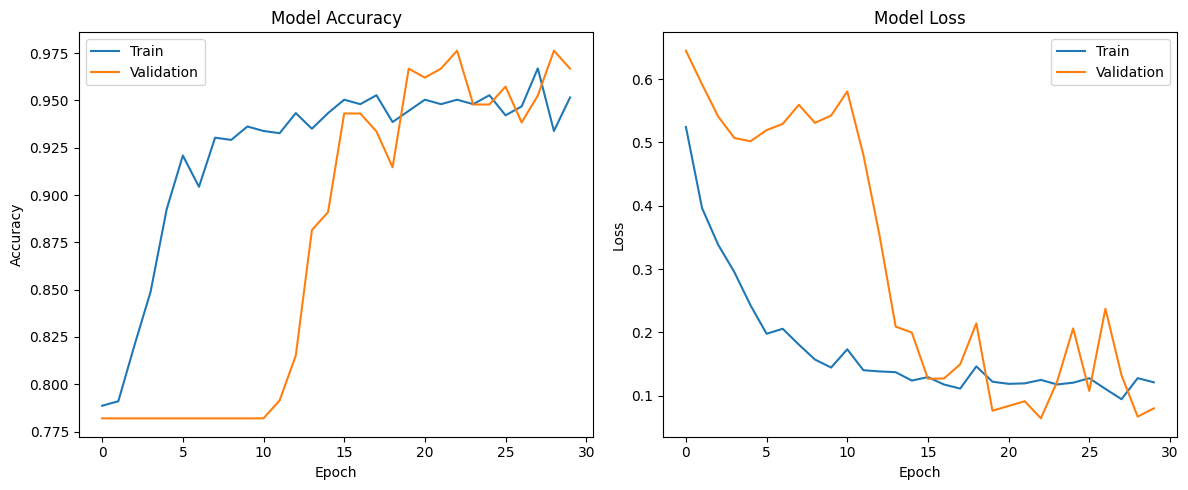

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop]
)

model.save('/kaggle/working/xception_logo_model.keras')
print("Модель успішно збережено!")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Оцінка моделі на валідаційних/тестових даних...
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step

--- ЗВІТ ПО МЕТРИКАХ ---
              precision    recall  f1-score   support

       Other       0.98      0.99      0.98       165
   Starbucks       0.95      0.91      0.93        46

    accuracy                           0.97       211
   macro avg       0.97      0.95      0.96       211
weighted avg       0.97      0.97      0.97       211



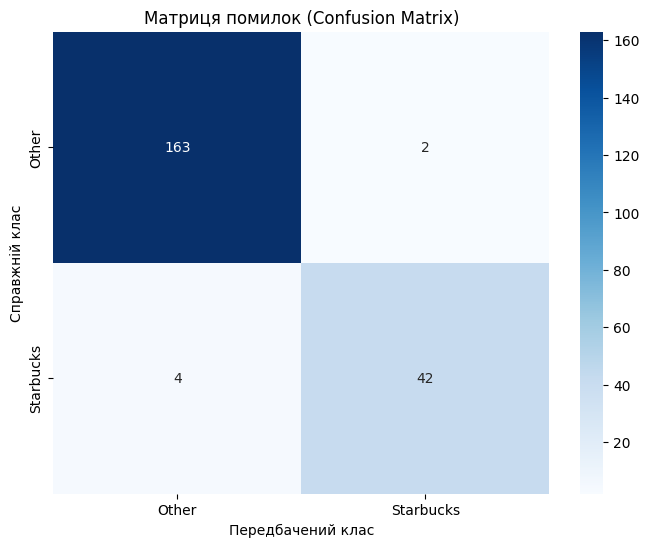

In [17]:
print("\nОцінка моделі на валідаційних/тестових даних...")

val_logits = model.predict(val_generator)
val_probs = tf.nn.sigmoid(val_logits).numpy().flatten()
val_preds = (val_probs > 0.5).astype(int)

true_labels = val_generator.classes

print("\n--- ЗВІТ ПО МЕТРИКАХ ---")
print(classification_report(true_labels, val_preds, target_names=class_names))

cm = confusion_matrix(true_labels, val_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матриця помилок (Confusion Matrix)')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.show()

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_video_for_logo(video_path, model, threshold=0.9, batch_size_video=32):

    if not os.path.exists(video_path):
        print(f"Відео не знайдено за шляхом {video_path}.")
        return

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0: 
        fps = 30.0
        
    frames = []
    frames_ids = []
    frame_predictions = []
    frame_numbers = []
    frame_count = 0
    
    def process_video_batch(batch_frames, batch_ids):
        batch_np = np.array(batch_frames).astype(np.float32) / 255.0
        predictions = model.predict(batch_np, verbose=0)
        
        for i in range(len(predictions)):
            score = 1 / (1 + np.exp(-predictions[i][0]))
            frame_predictions.append(score)
            frame_numbers.append(batch_ids[i])
            
    print(f"Починаємо обробку відео: {video_path}")
    print(f"FPS відео: {fps}")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        resized_frame = cv2.resize(frame, (150, 150))
        resized_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB) 
        
        frames.append(resized_frame)
        frames_ids.append(frame_count)
        
        if len(frames) == batch_size_video:
            process_video_batch(frames, frames_ids)
            frames = []
            frames_ids = []
            
        frame_count += 1
        if frame_count % 100 == 0:
            print(f"Оброблено кадрів: {frame_count}")
            
    if frames:
        process_video_batch(frames, frames_ids)
        
    cap.release()
    print("Обробку відео завершено.\n")
    
    appearances = []
    in_appearance = False
    start_frame = 0
    
    for i, score in enumerate(frame_predictions):
        if score > threshold and not in_appearance:
            in_appearance = True
            start_frame = frame_numbers[i]
        elif score <= threshold and in_appearance:
            in_appearance = False
            end_frame = frame_numbers[i-1]
            appearances.append((start_frame, end_frame))
            
    if in_appearance:
        appearances.append((start_frame, frame_numbers[-1]))

    print("-" * 40)
    print("ЗВІТ ПРО ВИЯВЛЕННЯ ЛОГОТИПУ:")
    print("-" * 40)
    
    if not appearances:
        print("Логотип не знайдено на цьому відео.")
    else:
        for i, (start_f, end_f) in enumerate(appearances, 1):
            start_time = start_f / fps
            end_time = end_f / fps
            duration = end_time - start_time
            
            start_str = f"{int(start_time // 60):02d}:{start_time % 60:05.2f}"
            end_str = f"{int(end_time // 60):02d}:{end_time % 60:05.2f}"
            
            print(f"Поява #{i}: з {start_str} по {end_str} (Тривалість: {duration:.2f} сек)")
    print("-" * 40)
    
    time_stamps = [f / fps for f in frame_numbers]
    plt.figure(figsize=(12, 6))
    plt.plot(time_stamps, frame_predictions, label='Ймовірність логотипу', color='green')
    plt.axhline(threshold, color='red', linestyle='--', label=f'Поріг виявлення = {threshold}')
    
    for start_f, end_f in appearances:
        plt.axvspan(start_f / fps, end_f / fps, color='green', alpha=0.2)
        
    plt.xlabel('Час відео (секунди)')
    plt.ylabel('Ймовірність (Score)')
    plt.title(f"Аналіз появи об'єкта: {os.path.basename(video_path)}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Починаємо обробку відео: /kaggle/input/datasets/vivdychenkomaksym/coffee-vid2/15604384_3840_2160_50fps.mp4
FPS відео: 50.0
Оброблено кадрів: 100
Оброблено кадрів: 200
Обробку відео завершено.

----------------------------------------
ЗВІТ ПРО ВИЯВЛЕННЯ ЛОГОТИПУ:
----------------------------------------
Поява #1: з 00:00.00 по 00:05.50 (Тривалість: 5.50 сек)
----------------------------------------


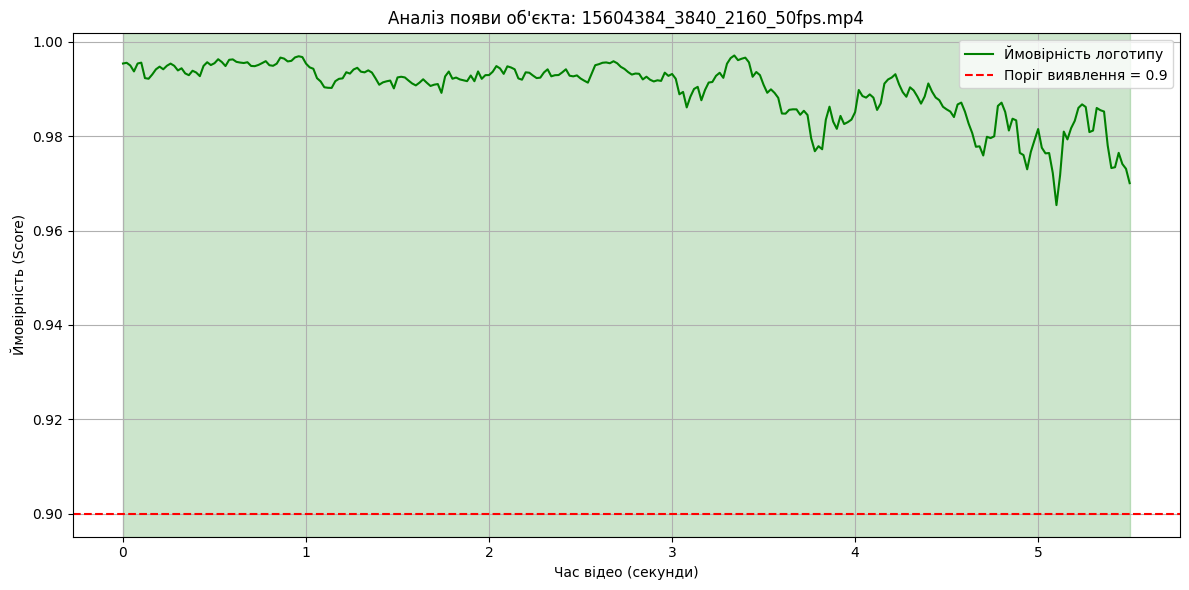

Починаємо обробку відео: /kaggle/input/datasets/vivdychenkomaksym/nature/12488732_640_360_30fps.mp4
FPS відео: 30.0
Оброблено кадрів: 100
Оброблено кадрів: 200
Оброблено кадрів: 300
Оброблено кадрів: 400
Оброблено кадрів: 500
Оброблено кадрів: 600
Оброблено кадрів: 700
Оброблено кадрів: 800
Оброблено кадрів: 900
Оброблено кадрів: 1000
Оброблено кадрів: 1100
Оброблено кадрів: 1200
Оброблено кадрів: 1300
Оброблено кадрів: 1400
Оброблено кадрів: 1500
Обробку відео завершено.

----------------------------------------
ЗВІТ ПРО ВИЯВЛЕННЯ ЛОГОТИПУ:
----------------------------------------
Логотип не знайдено на цьому відео.
----------------------------------------


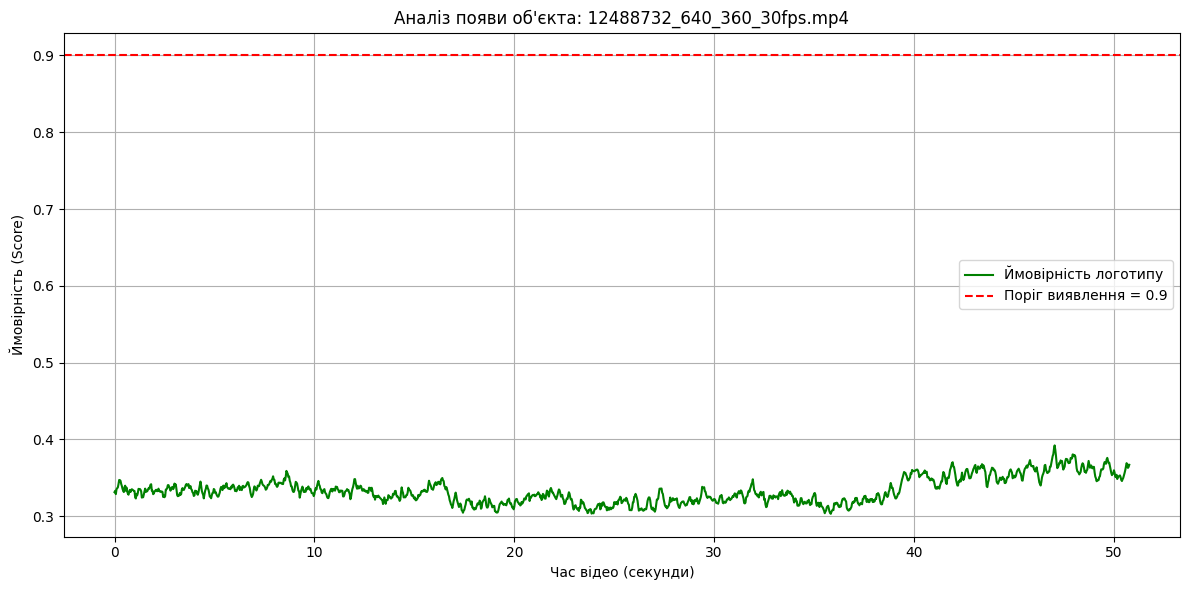

In [20]:
analyze_video_for_logo('/kaggle/input/datasets/vivdychenkomaksym/coffee-vid2/15604384_3840_2160_50fps.mp4', model)
analyze_video_for_logo('/kaggle/input/datasets/vivdychenkomaksym/nature/12488732_640_360_30fps.mp4', model)